In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.drop(columns=['Administrative','Informational'], axis = 1, inplace=True)

In [4]:
X = df.drop('Revenue', axis=1)

In [5]:
X['Weekend'] = X['Weekend'].astype(int)

In [6]:
cat_cols = ['Month', 'VisitorType']
num_cols = [col for col in X.columns if col not in cat_cols]

# ColumnTransformer

In [7]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', RobustScaler(), num_cols)
])

# KMeans Clustering

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=10)),
    ('model', KMeans(n_clusters=3, random_state=42))
])

k_labels = kmeans_pipe.fit_predict(X)

# score
X_trans = kmeans_pipe.named_steps['preprocessing'].transform(X)
X_pca = kmeans_pipe.named_steps['pca'].transform(X_trans)

print("KMeans Score:", silhouette_score(X_pca, k_labels))

KMeans Score: 0.8854028606775264


# ELBOW METHOD

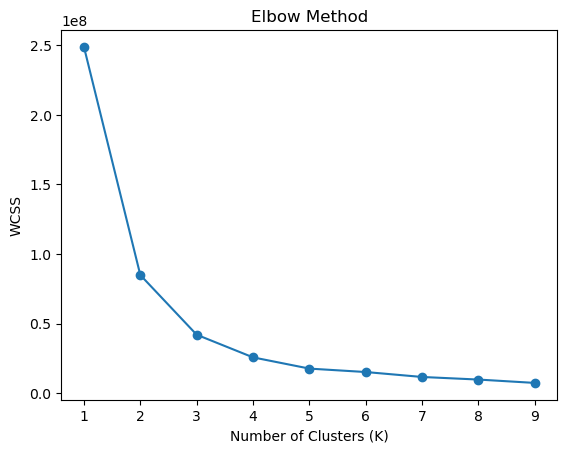

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Visualization

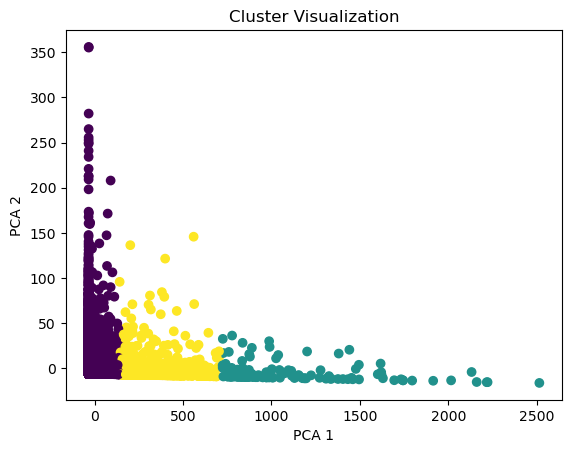

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization")
plt.show()

In [11]:
clusters = kmeans_pipe.predict(X)
df['Cluster'] = clusters

- Understaning of data

In [12]:
df.select_dtypes(include='number').groupby(df['Cluster']).mean()

,Administrative_Duration,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Cluster
Cluster,,,,,,,,,,,,,
0,71.635682,8.616713,29.181132,1075.197841,0.023041,0.044312,5.728691,0.063156,2.125043,2.365352,3.160549,4.095369,0.0
1,281.121432,1156.402639,101.931034,5271.310142,0.008226,0.023648,6.680040,0.037931,2.120690,2.318966,2.758621,3.431034,1.0
2,232.150422,343.738421,70.709386,2857.296198,0.007230,0.021054,9.103123,0.029964,2.102888,2.191336,2.951264,3.660650,2.0


In [13]:
pd.crosstab(df['Cluster'], df['Revenue'])

Revenue,False,True
Cluster,,
0,9942,1718
1,85,31
2,395,159


# DBSCAN (Density-Based Special Clustering of Applications With Noise)

In [14]:
from sklearn.cluster import DBSCAN

dbscan_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=10)),
    ('model', DBSCAN(eps=0.5, min_samples=5))
])

d_labels = dbscan_pipe.fit_predict(X)

# remove noise (-1)
import numpy as np
mask = d_labels != -1

if len(set(d_labels[mask])) > 1:
    print("DBSCAN Score:", silhouette_score(X_pca[mask], d_labels[mask]))
else:
    print("DBSCAN not good clustering")

DBSCAN Score: 0.012193546214922768


# Hierarchical Clustering

In [15]:
from sklearn.cluster import AgglomerativeClustering

hc_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=10)),
    ('model', AgglomerativeClustering(n_clusters=3))
])

h_labels = hc_pipe.fit_predict(X)

print("Hierarchical Score:", silhouette_score(X_pca, h_labels))

Hierarchical Score: 0.8442003397840465


In [16]:
print("KMeans:", silhouette_score(X_pca, k_labels))
print("Hierarchical:", silhouette_score(X_pca, h_labels))

KMeans: 0.8854028606775264
Hierarchical: 0.8442003397840465


# Dump into Pickle or joblib file

In [17]:
import joblib

joblib.dump(kmeans_pipe, "best_model.pkl")

['best_model.pkl']

- Testing

In [18]:
import pandas as pd

new_data = pd.DataFrame([{
    'Administrative_Duration': 50.0,
    'Informational_Duration': 20.0,
    'ProductRelated': 30,
    'ProductRelated_Duration': 300.0,
    'BounceRates': 0.02,
    'ExitRates': 0.04,
    'PageValues': 5.0,
    'SpecialDay': 0.0,
    'Month': 'May',
    'OperatingSystems': 2,
    'Browser': 1,
    'Region': 3,
    'TrafficType': 2,
    'VisitorType': 'Returning_Visitor',
    'Weekend': 1
}])

In [19]:
cluster = kmeans_pipe.predict(new_data)

print("Predicted Cluster:", cluster[0])

Predicted Cluster: 0


In [20]:
test_sample = X.iloc[[10]]   # pick any row

print("Actual cluster:", df.loc[10, 'Cluster'])

pred = kmeans_pipe.predict(test_sample)
print("Predicted cluster:", pred[0])

Actual cluster: 0
Predicted cluster: 0


In [21]:
sample_data = X.sample(5)

preds = kmeans_pipe.predict(sample_data)

print(preds)

[0 0 0 0 0]


In [22]:
import sklearn
print(sklearn.__version__)

1.6.1
